In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, FunctionTransformer

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df=pd.read_csv("development.csv")

In [3]:
df.shape

(5546, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5546 entries, 0 to 5545
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   catcher_id                 5546 non-null   int64  
 1   jobma_catcher_status       5546 non-null   int64  
 2   jobma_catcher_type         5546 non-null   int64  
 3   subscription_status        5546 non-null   int64  
 4   subscription_type          5546 non-null   int64  
 5   referral_credit            5546 non-null   int64  
 6   is_premium                 5546 non-null   int64  
 7   sub_user                   5546 non-null   int64  
 8   company_size               5546 non-null   object 
 9   per_sub_user               5546 non-null   float64
 10  number_of_logins           5546 non-null   float64
 11  jobma_login_status         5546 non-null   float64
 12  days_since_login           5546 non-null   float64
 13  wallet_sum                 5546 non-null   float

In [5]:
# Fill missing values in the DataFrame
def fill_missing_values(df):
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(0).astype(int)
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

df = fill_missing_values(df)

In [6]:
binary_columns = ['jobma_catcher_status',
                  'jobma_catcher_type',
                  'subscription_status',
                  'jobma_login_status',
                  'subscription_type',
                  'referral_credit',
                  'is_unlimited',
                  'is_premium',
                  'plan_type',
                  'currency'
                 ]

categorical_columns = ['company_size']
                   
ordinal_columns = ['sub_user',
                    'catcher_id',
                    'wallet_sum',
                    'per_sub_user',
                    'number_of_logins',
                    'days_since_login',
                    'subscription_sum',
                    'subscription_count',
                    'premium_plan_id',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'number_of_invitations',
                    'number_of_pitcher_applied',
                    'pre_rec_interviews_counts',
                    'live_interviews_counts',
                    'ai_kit_counts',
                    'ai_interviews_counts'
                   ]

In [8]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)


def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

# Clean ordinal values
def clean_ordinal(X):
    return X.clip(lower=0)

In [9]:
#Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                  ('scaler', StandardScaler())
                                 ])

#Categorical pipeline
categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                       ('scaler', StandardScaler())
                                      ])

#Ordinal pipeline
ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(log_transform, validate=False)),
                                   ('scaler', StandardScaler())
                                  ])

#Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns)
                                              ])

#pipeline
pipeline = Pipeline([('preprocessing', preprocessor)])

In [10]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x0000025ADA083490>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['jobma_catcher_status',
                                                   'jobma_catcher_type',
                                                   'subscription_status',
                                                   'jobma_login_status',
                                                   'subscripti...
                                                                   StandardScaler())]),
                                                  ['sub_user', 'catcher_id',
                                                   'wallet_sum', 'per_sub_user',
                                                   'number_of_logins',
                                                   'days_since_login',
                                                   'subscription_sum',
                                                   'subscription_count',
                                                   'premium_plan_id',
                                                   'pre_recorded_kit_counts',
                                                   'number_of_jobs_posted',
                                                   'number_of_invitations',
                                                   'number_of_pitcher_applied',
                                                   'pre_rec_interviews_counts',
                                                   'live_interviews_counts',
                                                   'ai_kit_counts',
                                                   'ai_interviews_counts'])]))])

In [11]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([5546, 32])

In [12]:
#Autoencoder and decoder model for word emedding
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [13]:
# Initialize model and Optimizers
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
batch_size = 16

In [14]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)
    

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 5/50, Loss: 6.0464
Epoch 10/50, Loss: 4.4929
Epoch 15/50, Loss: 3.2766
Epoch 20/50, Loss: 4.9375
Epoch 25/50, Loss: 1.4277
Epoch 30/50, Loss: 1.0363
Epoch 35/50, Loss: 1.4577
Epoch 40/50, Loss: 0.6790
Epoch 45/50, Loss: 1.4509
Epoch 50/50, Loss: 2.9296


In [15]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)

embeddings_np = embeddings.numpy()
embeddings_np.shape

(5546, 64)

In [16]:
type(embeddings_np)

numpy.ndarray

In [17]:
embeddings.shape

torch.Size([5546, 64])

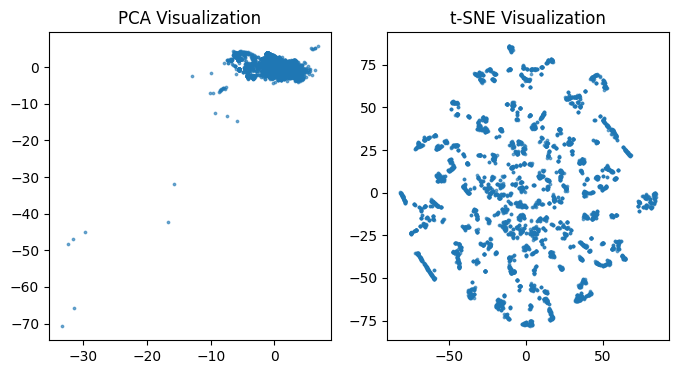

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)

# Plot PCA
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')

# Plot t-SNE
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()


In [26]:
#Recommend top N candidates based on cosine similarity.
#cosine similarity
# Sort by similarity

def recommend_client(query_index, embedings, top_n=5):
    similarities = cosine_similarity([embeddings[query_index]], embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n + 1]  # Include self in top candidates
    # top_indices = [idx for idx in top_indices if idx != query_index][:top_n]  # Exclude self-match

    # Display results
    print(f"\nTop {top_n} catcher_id for clients {query_index}:")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. Client {idx} - Similarity: {similarities[idx]:.4f}")

recommend_client(0, embeddings_np, top_n=11)


Top 11 catcher_id for clients 0:
1. Client 0 - Similarity: 1.0000
2. Client 724 - Similarity: 0.8903
3. Client 736 - Similarity: 0.8866
4. Client 732 - Similarity: 0.8845
5. Client 355 - Similarity: 0.8779
6. Client 651 - Similarity: 0.8755
7. Client 726 - Similarity: 0.8733
8. Client 720 - Similarity: 0.8702
9. Client 1163 - Similarity: 0.8698
10. Client 779 - Similarity: 0.8697
11. Client 912 - Similarity: 0.8696
12. Client 731 - Similarity: 0.8690


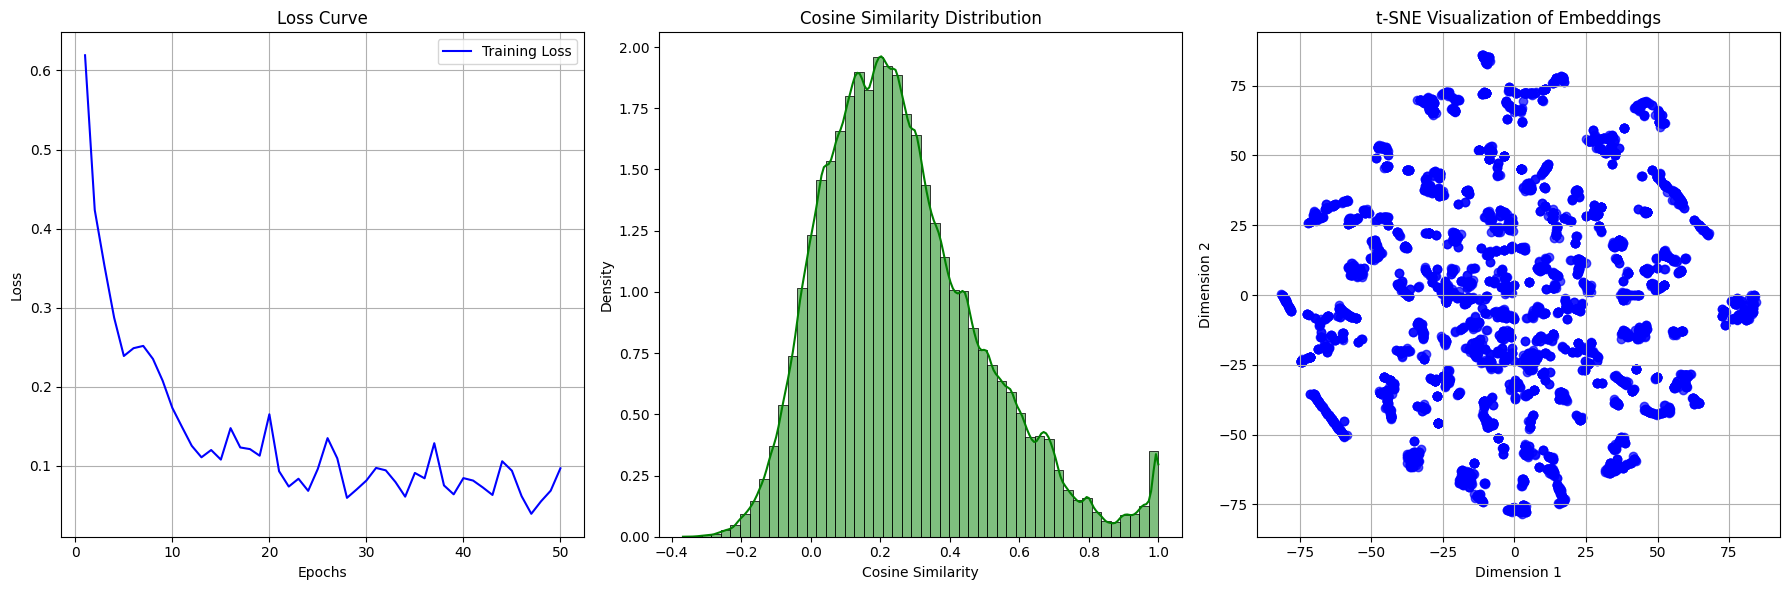

In [20]:
from sklearn.manifold import TSNE
# 1. Plotting the Loss Curve  # 2. Cosine Similarity Distribution  # 3. t-SNE Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Adjust the size as needed
axs[0].plot(range(1, epochs + 1), loss_history, label='Training Loss', color='blue')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Loss Curve')
axs[0].grid(True)
axs[0].legend()

similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=axs[1])
axs[1].set_title('Cosine Similarity Distribution')
axs[1].set_xlabel('Cosine Similarity')
axs[1].set_ylabel('Density')

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_np)
axs[2].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.7)
axs[2].set_title('t-SNE Visualization of Embeddings')
axs[2].set_xlabel('Dimension 1')
axs[2].set_ylabel('Dimension 2')
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [21]:
df.iloc[355]

catcher_id                    984
jobma_catcher_status            1
jobma_catcher_type              1
subscription_status             2
subscription_type               0
referral_credit                 0
is_premium                      1
sub_user                      999
company_size                 1-25
per_sub_user                  100
number_of_logins                1
jobma_login_status              0
days_since_login             2606
wallet_sum                     30
plan_type                       0
is_unlimited                    0
subscription_sum               99
subscription_count              1
currency                        0
premium_plan_id                 3
pre_recorded_kit_counts         2
number_of_jobs_posted           2
number_of_invitations           8
number_of_pitcher_applied      17
pre_rec_interviews_counts      11
live_interviews_counts          3
ai_kit_counts                   0
ai_interviews_counts            0
Name: 355, dtype: object

In [22]:
df.iloc[720]

catcher_id                   1520
jobma_catcher_status            1
jobma_catcher_type              1
subscription_status             2
subscription_type               0
referral_credit                 0
is_premium                      1
sub_user                      999
company_size                 1-25
per_sub_user                  100
number_of_logins                1
jobma_login_status              0
days_since_login             2304
wallet_sum                    694
plan_type                       0
is_unlimited                    0
subscription_sum               99
subscription_count              1
currency                        0
premium_plan_id                 3
pre_recorded_kit_counts         7
number_of_jobs_posted          31
number_of_invitations          63
number_of_pitcher_applied      80
pre_rec_interviews_counts      61
live_interviews_counts         11
ai_kit_counts                   0
ai_interviews_counts            0
Name: 720, dtype: object

In [23]:
df.iloc[759]

catcher_id                   1637
jobma_catcher_status            1
jobma_catcher_type              1
subscription_status             2
subscription_type               0
referral_credit                 0
is_premium                      1
sub_user                      999
company_size                 1-25
per_sub_user                  100
number_of_logins                1
jobma_login_status              0
days_since_login             2261
wallet_sum                    197
plan_type                       0
is_unlimited                    0
subscription_sum              199
subscription_count              1
currency                        0
premium_plan_id                 3
pre_recorded_kit_counts         2
number_of_jobs_posted          12
number_of_invitations          29
number_of_pitcher_applied       3
pre_rec_interviews_counts       2
live_interviews_counts          1
ai_kit_counts                   0
ai_interviews_counts            0
Name: 759, dtype: object

In [24]:
recommend_client(2, embeddings, top_n=5)


Top 5 catcher_id for clients 2:
1. Client 4 - Similarity: 1.0000
2. Client 7 - Similarity: 0.9998
3. Client 6 - Similarity: 0.9998
4. Client 15 - Similarity: 0.9996
5. Client 17 - Similarity: 0.9993


In [25]:
df

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
0,92,1,1,2,0,0,1,999,1-25,100,...,0,3,2,825,7,17640,3,2,0,0
1,106,0,0,2,0,0,1,999,1-25,100,...,0,3,0,0,0,0,0,0,0,0
2,124,1,0,2,0,0,1,999,1-25,100,...,0,3,0,1,0,3,0,0,0,0
3,125,1,0,2,0,0,1,999,1-25,100,...,0,3,0,0,0,0,0,0,0,0
4,126,1,0,2,0,0,1,999,1-25,100,...,0,3,0,1,0,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5541,9319,1,1,1,0,0,0,999,1-25,100,...,1,4,1,400,1,1,1,0,0,0
5542,9365,1,1,1,0,0,1,21,26-100,100,...,0,2,0,4,25,5,7,0,0,0
5543,9405,1,1,1,0,0,0,999,1-25,100,...,1,4,0,0,0,0,0,0,0,0
5544,9413,1,1,1,0,0,0,10,101-500,100,...,0,3,1,2,3,0,0,0,0,0
